# Лабораторная работа: Ансамбли моделей машинного обучения. Часть 2

**Цель работы:** Изучение ансамблевых моделей машинного обучения на примере датасета Fish Market.

## 1. Описание датасета и импорт необходимых библиотек

В данной работе используется датасет **Fish Market** с платформы Kaggle.  
Датасет содержит 159 образцов рыб, каждый из которых характеризуется следующими признаками:
*   `Species` — вид рыбы (категориальный признак)
*   `Weight` — вес рыбы в граммах (целевая переменная)
*   `Length1`, `Length2`, `Length3` — различные измерения длины в сантиметрах
*   `Height` — высота рыбы в сантиметрах
*   `Width` — ширина рыбы в сантиметрах

**Задача регрессии:** прогнозирование веса рыбы (`Weight`) на основе её вида и физических размеров.

Датасет не содержит пропущенных значений, однако содержит один категориальный признак (`Species`), который потребует кодирования.

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Импорт датасетов и функций sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Импорт метрик
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Импорт моделей
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# Импорт визуализаций
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

from operator import itemgetter

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


In [4]:
from sklearn.ensemble import StackingRegressor

from gmdhpy import gmdh

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


In [6]:
def vis_models_quality(array_metric, array_labels, str_header, figsize=(8, 5)):
    fig, ax1 = plt.subplots(figsize=figsize)
    pos = np.arange(len(array_metric))
    rects = ax1.barh(pos, array_metric,
                     align='center',
                     height=0.5, 
                     tick_label=array_labels)
    ax1.set_title(str_header)
    for a, b in zip(pos, array_metric):
        plt.text(0.1, a-0.1, str(round(b, 3)), color='white', fontsize=10)
    plt.tight_layout()
    plt.show()

## 2. Загрузка и исследование датасета

Загружаем данные и создаем DataFrame для удобства анализа. Проверим размерность, отсутствие пропусков и посмотрим на распределение видов рыб.

In [7]:
# Загрузка датасета
df = pd.read_csv('Fish.csv')

print("Размерность датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о датасете:")
df.info()

Размерность датасета: (159, 7)

Первые 5 строк:


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


Количество пропущенных значений:
Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

Распределение видов рыб:
Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64


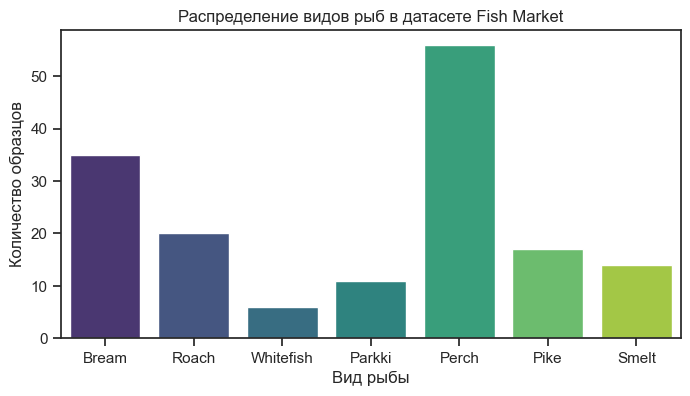

In [8]:
# Проверка на пропуски
print("Количество пропущенных значений:")
print(df.isnull().sum())

# Распределение видов рыб
print("\nРаспределение видов рыб:")
print(df['Species'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Species', hue='Species', palette='viridis', legend=False)
plt.title('Распределение видов рыб в датасете Fish Market')
plt.ylabel('Количество образцов')
plt.xlabel('Вид рыбы')
plt.show()

Описательная статистика числовых признаков:


,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


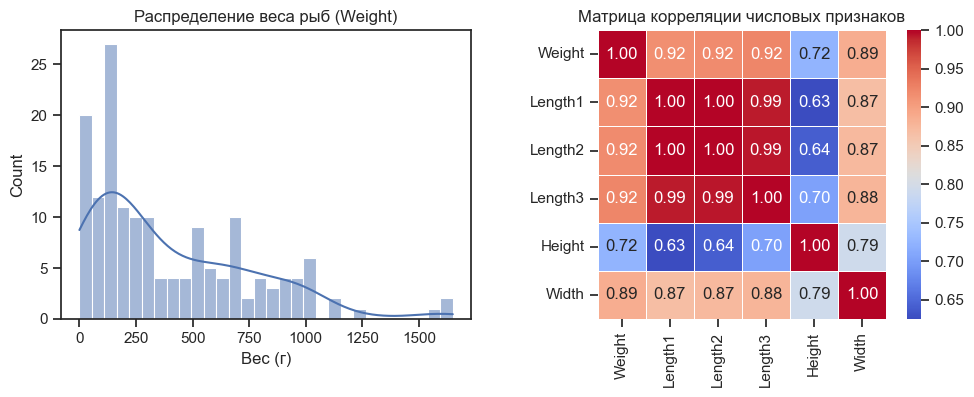

In [9]:
# Описательная статистика числовых признаков
print("Описательная статистика числовых признаков:")
display(df.describe())

# Распределение целевой переменной
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Weight'], bins=30, kde=True)
plt.title('Распределение веса рыб (Weight)')
plt.xlabel('Вес (г)')

plt.subplot(1, 2, 2)
numeric_cols = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Матрица корреляции числовых признаков')
plt.tight_layout()
plt.show()

**Выводы по исследованию данных:**
*   Датасет содержит 159 записей и 7 столбцов (6 признаков + целевая переменная).
*   Пропущенные значения отсутствуют.
*   Присутствует один категориальный признак `Species` (7 видов рыб), который требует кодирования.
*   Наблюдается сильная корреляция между размерами рыбы и её весом (особенно `Length3` и `Weight`).

## 3. Предобработка данных и разделение на выборки

Выполним следующие шаги предобработки:
1.  **Кодирование категориального признака** `Species` с помощью One-Hot Encoding.
2.  **Масштабирование числовых признаков** с помощью StandardScaler (обязательно для MLPRegressor!).
3.  **Разделение** на обучающую и тестовую выборки в соотношении 80/20.

In [10]:
# Разделяем признаки и целевую переменную
X = df.drop('Weight', axis=1)
y = df['Weight']

# Определяем типы признаков
categorical_features = ['Species']
numeric_features = ['Length1', 'Length2', 'Length3', 'Height', 'Width']

# Создаем преобразователь
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Применяем преобразования ко всему датасету
X_processed = preprocessor.fit_transform(X)

# Получаем имена признаков после One-Hot Encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_feature_names)
print("Итоговые признаки:", all_feature_names)
print("Размерность после предобработки:", X_processed.shape)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nДиапазон веса в обучающей выборке: [{y_train.min():.1f}, {y_train.max():.1f}] г")
print(f"Диапазон веса в тестовой выборке: [{y_test.min():.1f}, {y_test.max():.1f}] г")

Итоговые признаки: ['Length1', 'Length2', 'Length3', 'Height', 'Width', 'Species_Parkki', 'Species_Perch', 'Species_Pike', 'Species_Roach', 'Species_Smelt', 'Species_Whitefish']
Размерность после предобработки: (159, 11)

Размер обучающей выборки: (127, 11)
Размер тестовой выборки: (32, 11)

Диапазон веса в обучающей выборке: [0.0, 1650.0] г
Диапазон веса в тестовой выборке: [6.7, 1250.0] г


## 4. Обучение ансамблевых моделей

**4.1**
Согласно заданию, мы обучим следующие модели:
1.  **Модель стекинга** — одна из моделей группы стекинга (с использованием библиотеки `heamy`).
2.  **Многослойный персептрон** — модель MLPRegressor из библиотеки scikit-learn.
3.  **Модели МГУА** — линейный метод (COMBI) и нелинейный метод (MULTI/RIA) с использованием библиотеки `gmdhpy`.



In [28]:
# Словарь для хранения результатов
all_models_results = {}


### 4.2. Модель стекинга

Реализуем стекинг:
*   **Модели 1 уровня:** Decision Tree, Linear Regression, Random Forest
*   **Мета-ученик (уровень 2):** Linear Regression
*   **Кросс-валидация:** 10 фолдов

In [29]:
print("=== Модель стекинга (Tree + LR + RF => LR) ===\n")

# Модели первого уровня
base_estimators = [
    ('tree', DecisionTreeRegressor(random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42))
]

# Мета-ученик (уровень 2)
meta_estimator = LinearRegression()

# Создаём модель стекинга
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    cv=10,  # 10-фолдовая кросс-валидация (как в heamy)
    passthrough=False
)

# Обучаем модель
stacking_model.fit(X_train, y_train)

# Предсказание
y_pred_stack = stacking_model.predict(X_test)

mae_stack = mean_absolute_error(y_test, y_pred_stack)
mse_stack = mean_squared_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)

all_models_results['Stacking (Tree+RF→LR)'] = {
    'MAE': mae_stack, 'MSE': mse_stack, 'R²': r2_stack, 'predictions': y_pred_stack
}

print(f"Результаты стекинга на тестовой выборке:")
print(f"  MAE = {mae_stack:.4f}")
print(f"  MSE = {mse_stack:.4f}")
print(f"  R²  = {r2_stack:.4f}")
print(f"  Кросс-валидация: 10 фолдов")
print("-" * 40)

=== Модель стекинга (Tree + LR + RF => LR) ===

Результаты стекинга на тестовой выборке:
  MAE = 41.4888
  MSE = 3053.2759
  R²  = 0.9785
  Кросс-валидация: 10 фолдов
----------------------------------------


### 4.3. Многослойный персептрон (MLPRegressor)

Обучим модель MLPRegressor из scikit-learn. Согласно документации, MLP чувствителен к масштабированию признаков (мы уже применили StandardScaler). Используем:
*   Два скрытых слоя: 100 и 50 нейронов
*   Функция активации: ReLU
*   Оптимизатор: Adam
*   L2-регуляризация: alpha=0.001
*   Ранняя остановка: включена

In [30]:
print("=== Многослойный персептрон (MLPRegressor) ===\n")

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),   # два скрытых слоя
    activation='relu',              # функция активации
    solver='adam',                  # оптимизатор
    alpha=0.001,                    # L2-регуляризация
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42,
    early_stopping=True,            # ранняя остановка
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=False
)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

all_models_results['MLP Regressor'] = {
    'MAE': mae_mlp, 'MSE': mse_mlp, 'R²': r2_mlp, 'predictions': y_pred_mlp
}

print(f"MLPRegressor результаты:")
print(f"  MAE  = {mae_mlp:.4f}")
print(f"  MSE  = {mse_mlp:.4f}")
print(f"  R²   = {r2_mlp:.4f}")
print(f"  Количество итераций: {mlp.n_iter_}")
print(f"  Финальная функция потерь: {mlp.loss_:.4f}")
print("-" * 40)

=== Многослойный персептрон (MLPRegressor) ===

MLPRegressor результаты:
  MAE  = 72.8613
  MSE  = 6488.3988
  R²   = 0.9544
  Количество итераций: 294
  Финальная функция потерь: 2412.9159
----------------------------------------


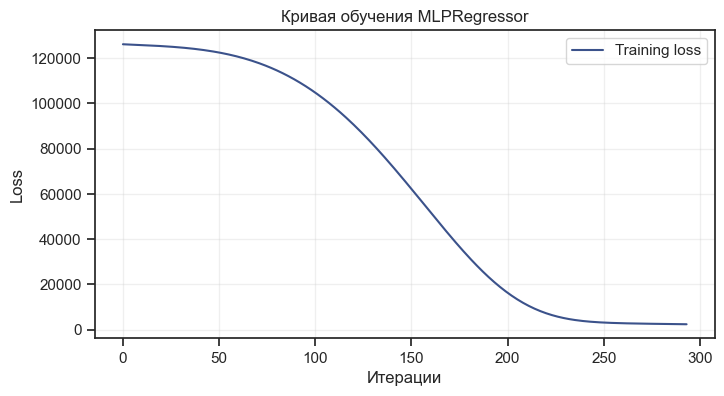

In [31]:
# Визуализация кривой обучения MLP
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label='Training loss', color='#3b528b')
plt.title('Кривая обучения MLPRegressor')
plt.xlabel('Итерации')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4.4. Модели МГУА (GMDH)

Согласно заданию, обучим два метода из семейства МГУА:
1.  **Линейный метод (COMBI)** — используется по умолчанию в `gmdh.Regressor()`.
2.  **Нелинейный метод (MULTI/RIA)** — с набором опорных функций `('linear_cov', 'quadratic', 'cubic', 'linear')`, как показано в лекциях преподавателя.

**Примечание:** МГУА автоматически использует валидационную выборку для предотвращения переобучения (внешний критерий).

In [32]:
print("=== Модели МГУА (GMDH) ===\n")

from gmdhpy.gmdh import MultilayerGMDH

# Преобразуем данные в numpy массивы (обязательно для gmdhpy!)
# Если X_train уже numpy массив после предобработки — ок, но y_train точно pandas Series
X_train_np = np.asarray(X_train, dtype=float)
y_train_np = np.asarray(y_train, dtype=float)
X_test_np = np.asarray(X_test, dtype=float)

print(f"Тип X_train: {type(X_train_np)}, форма: {X_train_np.shape}")
print(f"Тип y_train: {type(y_train_np)}, форма: {y_train_np.shape}")
print()

# Модель 1: COMBI (линейный метод)
print("1. COMBI (линейный метод):")
model_gmdh_combi = MultilayerGMDH()
model_gmdh_combi.fit(X_train_np, y_train_np)
y_pred_combi = model_gmdh_combi.predict(X_test_np)

mae_combi = mean_absolute_error(y_test, y_pred_combi)
mse_combi = mean_squared_error(y_test, y_pred_combi)
r2_combi = r2_score(y_test, y_pred_combi)

all_models_results['МГУА COMBI (линейный)'] = {
    'MAE': mae_combi, 'MSE': mse_combi, 'R²': r2_combi, 'predictions': y_pred_combi
}

print(f"  MAE = {mae_combi:.4f}")
print(f"  MSE = {mse_combi:.4f}")
print(f"  R²  = {r2_combi:.4f}")
print()

# Модель 2: MULTI (нелинейный метод)
print("2. MULTI (нелинейный метод с quadratic, cubic):")
model_gmdh_multi = MultilayerGMDH(
    ref_functions=('linear_cov', 'quadratic', 'cubic', 'linear')
)
model_gmdh_multi.fit(X_train_np, y_train_np)
y_pred_multi = model_gmdh_multi.predict(X_test_np)

mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

all_models_results['МГУА MULTI (нелинейный)'] = {
    'MAE': mae_multi, 'MSE': mse_multi, 'R²': r2_multi, 'predictions': y_pred_multi
}

print(f"  MAE = {mae_multi:.4f}")
print(f"  MSE = {mse_multi:.4f}")
print(f"  R²  = {r2_multi:.4f}")
print("-" * 40)

=== Модели МГУА (GMDH) ===

Тип X_train: <class 'numpy.ndarray'>, форма: (127, 11)
Тип y_train: <class 'numpy.ndarray'>, форма: (127,)

1. COMBI (линейный метод):
train layer0 in 0.15 sec
train layer1 in 0.54 sec
train layer2 in 0.49 sec
train layer3 in 0.43 sec
train layer4 in 0.42 sec
train layer5 in 0.52 sec
train layer6 in 0.50 sec
train layer7 in 0.53 sec
train layer8 in 0.42 sec
train layer9 in 0.44 sec
  MAE = 45.2088
  MSE = 4088.9080
  R²  = 0.9713

2. MULTI (нелинейный метод с quadratic, cubic):
train layer0 in 0.52 sec
train layer1 in 1.88 sec
train layer2 in 1.87 sec
train layer3 in 2.38 sec
train layer4 in 1.95 sec
train layer5 in 2.17 sec
train layer6 in 2.68 sec
train layer7 in 2.32 sec
train layer8 in 2.57 sec
train layer9 in 2.07 sec
train layer10 in 2.33 sec
train layer11 in 2.12 sec
train layer12 in 2.13 sec
train layer13 in 2.27 sec
train layer14 in 2.16 sec
  MAE = 64.0271
  MSE = 13577.8112
  R²  = 0.9045
----------------------------------------


## 5. Сравнение качества моделей

Сравним все обученные модели по метрикам MAE, MSE и R².  
Для задачи регрессии это стандартные метрики:
*   **MAE (Mean Absolute Error)** — средняя абсолютная ошибка в граммах.
*   **MSE (Mean Squared Error)** — среднеквадратичная ошибка.
*   **R² (Coefficient of determination)** — коэффициент детерминации (чем ближе к 1, тем лучше).

In [36]:
# Сводная таблица результатов
print("=== Сводная таблица результатов ===\n")

summary_data = []
for name, metrics in all_models_results.items():
    summary_data.append({
        'Модель': name,
        'MAE': metrics['MAE'],
        'MSE': metrics['MSE'],
        'R²': metrics['R²']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('MAE').reset_index(drop=True)
summary_df.index = summary_df.index + 1
summary_df.index.name = 'Место'

print(summary_df.to_string(float_format=lambda x: f'{x:.4f}'))

=== Сводная таблица результатов ===

                        Модель     MAE        MSE     R²
Место                                                   
1        Stacking (Tree+RF→LR) 41.4888  3053.2759 0.9785
2        МГУА COMBI (линейный) 45.2088  4088.9080 0.9713
3      МГУА MULTI (нелинейный) 64.0271 13577.8112 0.9045
4                MLP Regressor 72.8613  6488.3988 0.9544


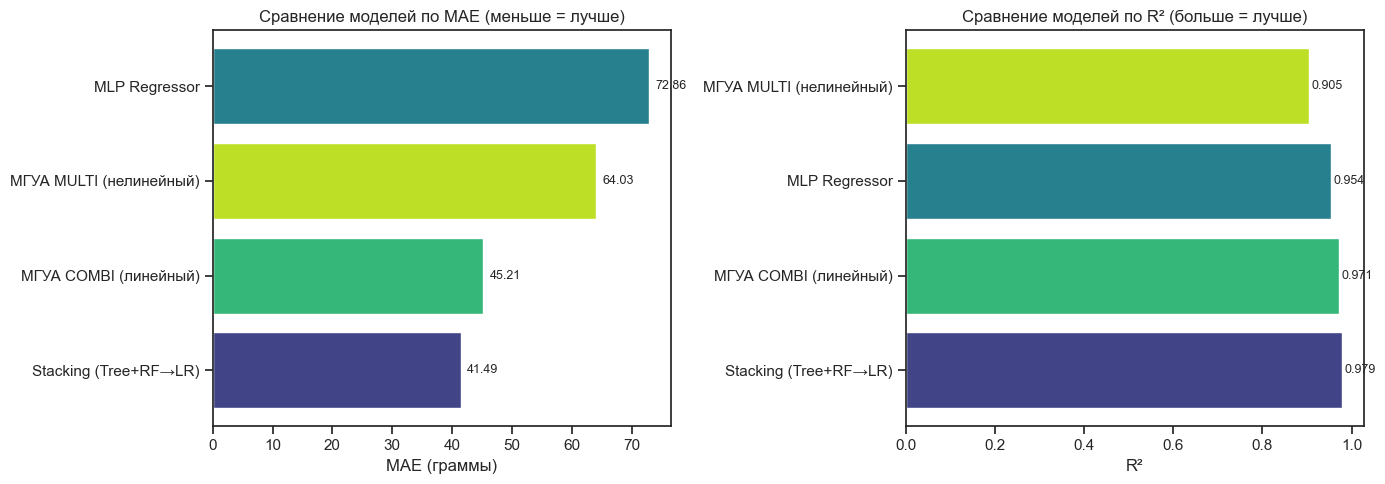

In [37]:
# Визуализация сравнения по MAE и R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_names = list(all_models_results.keys())
models_mae = [all_models_results[m]['MAE'] for m in models_names]
models_r2 = [all_models_results[m]['R²'] for m in models_names]

# Сортировка по MAE
sorted_idx_mae = np.argsort(models_mae)

# График MAE
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(models_names)))
axes[0].barh(range(len(models_names)), [models_mae[i] for i in sorted_idx_mae], 
            color=[colors[i] for i in sorted_idx_mae])
axes[0].set_yticks(range(len(models_names)))
axes[0].set_yticklabels([models_names[i] for i in sorted_idx_mae])
axes[0].set_title('Сравнение моделей по MAE (меньше = лучше)')
axes[0].set_xlabel('MAE (граммы)')
for i, (idx, val) in enumerate(zip(sorted_idx_mae, [models_mae[i] for i in sorted_idx_mae])):
    axes[0].text(val + 1, i, f'{val:.2f}', va='center', fontsize=9)

# График R²
sorted_idx_r2 = np.argsort(models_r2)[::-1]
axes[1].barh(range(len(models_names)), [models_r2[i] for i in sorted_idx_r2],
            color=[colors[i] for i in sorted_idx_r2])
axes[1].set_yticks(range(len(models_names)))
axes[1].set_yticklabels([models_names[i] for i in sorted_idx_r2])
axes[1].set_title('Сравнение моделей по R² (больше = лучше)')
axes[1].set_xlabel('R²')
for i, (idx, val) in enumerate(zip(sorted_idx_r2, [models_r2[i] for i in sorted_idx_r2])):
    axes[1].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

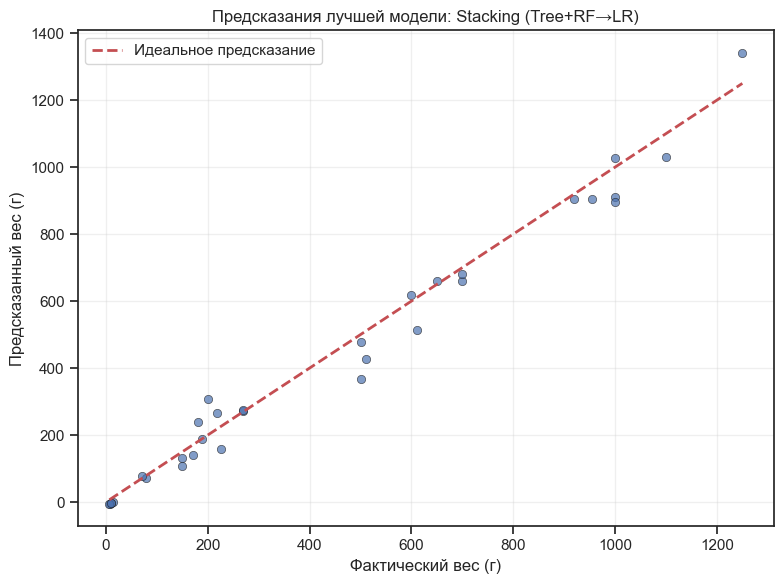

In [38]:
# Визуализация предсказаний лучшей модели
best_model_name = summary_df.iloc[0]['Модель']
y_pred_best = all_models_results[best_model_name]['predictions']

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Фактический вес (г)')
plt.ylabel('Предсказанный вес (г)')
plt.title(f'Предсказания лучшей модели: {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Анализ важности признаков

Для моделей на основе деревьев (Random Forest, Gradient Boosting) проанализируем важность признаков.  
Это поможет понять, какие характеристики рыб наиболее значимы для прогнозирования их веса.

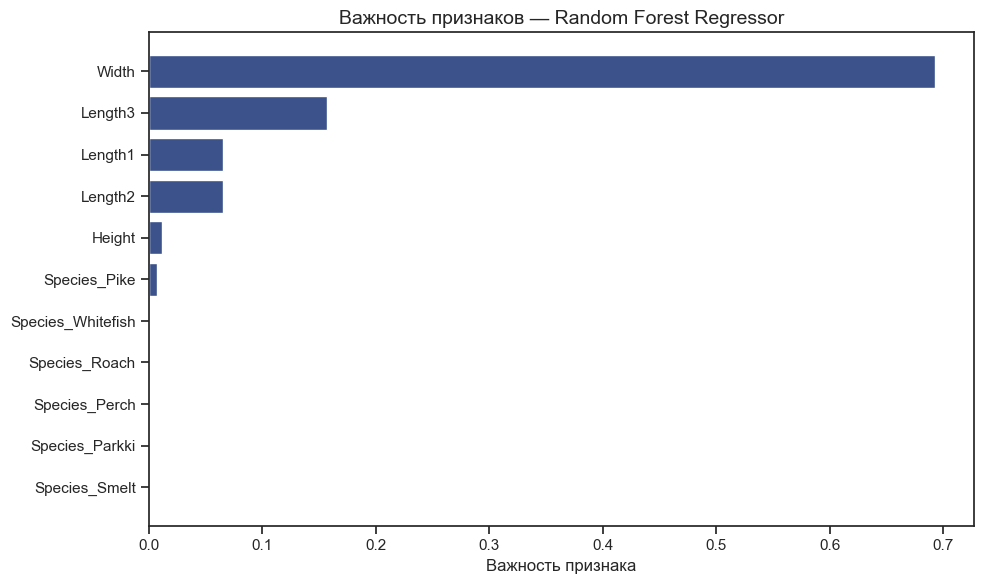

Топ-5 важных признаков для Random Forest:
  Width: 0.6925
  Length3: 0.1566
  Length1: 0.0658
  Length2: 0.0656
  Height: 0.0116


In [26]:
# Важность признаков для Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Важность признаков — Random Forest Regressor', fontsize=14)
plt.barh(range(len(indices)), importances[indices], align='center', color='#3b528b')
plt.yticks(range(len(indices)), [all_feature_names[i] for i in indices])
plt.xlabel('Важность признака')
plt.tight_layout()
plt.show()

print("Топ-5 важных признаков для Random Forest:")
for i in indices[::-1][:5]:
    print(f"  {all_feature_names[i]}: {importances[i]:.4f}")

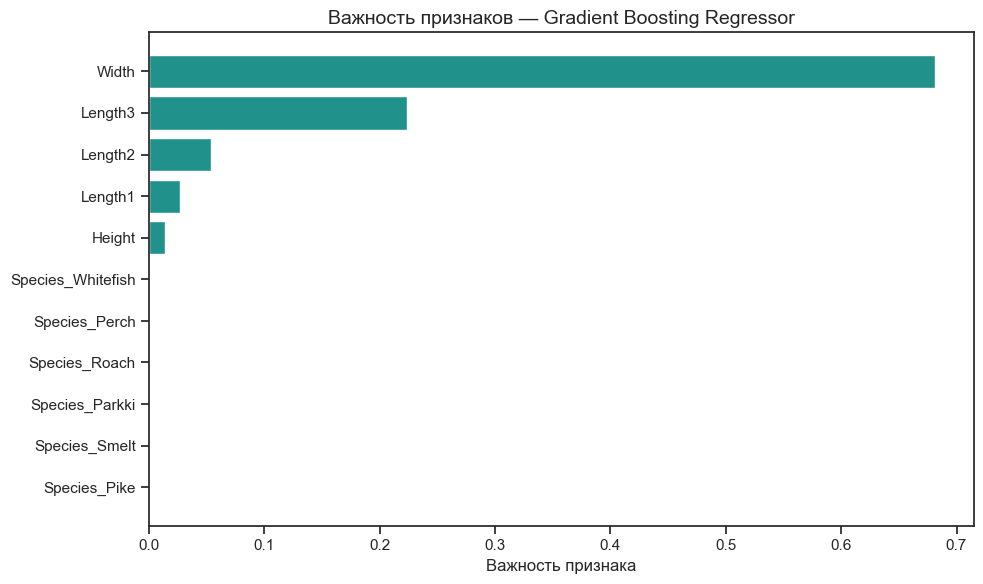

Топ-5 важных признаков для Gradient Boosting:
  Width: 0.6811
  Length3: 0.2237
  Length2: 0.0538
  Length1: 0.0273
  Height: 0.0140


In [27]:
# Важность признаков для Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

importances_gb = gb_model.feature_importances_
indices_gb = np.argsort(importances_gb)

plt.figure(figsize=(10, 6))
plt.title('Важность признаков — Gradient Boosting Regressor', fontsize=14)
plt.barh(range(len(indices_gb)), importances_gb[indices_gb], align='center', color='#21918c')
plt.yticks(range(len(indices_gb)), [all_feature_names[i] for i in indices_gb])
plt.xlabel('Важность признака')
plt.tight_layout()
plt.show()

print("Топ-5 важных признаков для Gradient Boosting:")
for i in indices_gb[::-1][:5]:
    print(f"  {all_feature_names[i]}: {importances_gb[i]:.4f}")